In [3]:
import pandas as pd
import os

DATA_FOLDER = "."  # update this path

FILE_2022 = "MUP_PHY_R25_P05_V20_D22_Prov_Svc.csv"
FILE_2023 = "MUP_PHY_R25_P05_V20_D23_Prov_Svc.csv"

SPECIALTIES = ["Cardiology", "Internal Medicine", "Family Practice"]

print("Loading 2022 data...")
df_2022 = pd.read_csv(os.path.join(DATA_FOLDER, FILE_2022), low_memory=False)
df_2022["year"] = 2022

print("Loading 2023 data...")
df_2023 = pd.read_csv(os.path.join(DATA_FOLDER, FILE_2023), low_memory=False)
df_2023["year"] = 2023

df = pd.concat([df_2022, df_2023], ignore_index=True)
print(f"\nTotal rows loaded: {len(df):,}")

print("\nColumn names:")
print(df.columns.tolist())

df_filtered = df[df["Rndrng_Prvdr_Type"].isin(SPECIALTIES)].copy()
print(f"\nRows after specialty filter: {len(df_filtered):,}")

print("\nRow counts by specialty and year:")
print(df_filtered.groupby(["Rndrng_Prvdr_Type", "year"]).size())

Loading 2022 data...
Loading 2023 data...

Total rows loaded: 19,416,074

Column names:
['Rndrng_NPI', 'Rndrng_Prvdr_Last_Org_Name', 'Rndrng_Prvdr_First_Name', 'Rndrng_Prvdr_MI', 'Rndrng_Prvdr_Crdntls', 'Rndrng_Prvdr_Ent_Cd', 'Rndrng_Prvdr_St1', 'Rndrng_Prvdr_St2', 'Rndrng_Prvdr_City', 'Rndrng_Prvdr_State_Abrvtn', 'Rndrng_Prvdr_State_FIPS', 'Rndrng_Prvdr_Zip5', 'Rndrng_Prvdr_RUCA', 'Rndrng_Prvdr_RUCA_Desc', 'Rndrng_Prvdr_Cntry', 'Rndrng_Prvdr_Type', 'Rndrng_Prvdr_Mdcr_Prtcptg_Ind', 'HCPCS_Cd', 'HCPCS_Desc', 'HCPCS_Drug_Ind', 'Place_Of_Srvc', 'Tot_Benes', 'Tot_Srvcs', 'Tot_Bene_Day_Srvcs', 'Avg_Sbmtd_Chrg', 'Avg_Mdcr_Alowd_Amt', 'Avg_Mdcr_Pymt_Amt', 'Avg_Mdcr_Stdzd_Amt', 'year']

Rows after specialty filter: 4,027,496

Row counts by specialty and year:
Rndrng_Prvdr_Type  year
Cardiology         2022    385653
                   2023    381081
Family Practice    2022    813473
                   2023    770162
Internal Medicine  2022    868292
                   2023    808835
dtype: int

In [4]:
for col in df_filtered.columns.tolist():
    print(col)

Rndrng_NPI
Rndrng_Prvdr_Last_Org_Name
Rndrng_Prvdr_First_Name
Rndrng_Prvdr_MI
Rndrng_Prvdr_Crdntls
Rndrng_Prvdr_Ent_Cd
Rndrng_Prvdr_St1
Rndrng_Prvdr_St2
Rndrng_Prvdr_City
Rndrng_Prvdr_State_Abrvtn
Rndrng_Prvdr_State_FIPS
Rndrng_Prvdr_Zip5
Rndrng_Prvdr_RUCA
Rndrng_Prvdr_RUCA_Desc
Rndrng_Prvdr_Cntry
Rndrng_Prvdr_Type
Rndrng_Prvdr_Mdcr_Prtcptg_Ind
HCPCS_Cd
HCPCS_Desc
HCPCS_Drug_Ind
Place_Of_Srvc
Tot_Benes
Tot_Srvcs
Tot_Bene_Day_Srvcs
Avg_Sbmtd_Chrg
Avg_Mdcr_Alowd_Amt
Avg_Mdcr_Pymt_Amt
Avg_Mdcr_Stdzd_Amt
year


In [5]:
# --- Step 2: State-level benchmarking by specialty ---
# For each state + specialty combination, calculate:
#   - Average Medicare payment per service
#   - Average submitted charge per service  
#   - Total services (volume)
#   - Charge-to-payment ratio (a fraud/billing intensity signal)

state_summary = (
    df_filtered
    .groupby(["Rndrng_Prvdr_State_Abrvtn", "Rndrng_Prvdr_Type", "year"])
    .agg(
        avg_payment  = ("Avg_Mdcr_Pymt_Amt", "mean"),
        avg_charge   = ("Avg_Sbmtd_Chrg",    "mean"),
        total_srvcs  = ("Tot_Srvcs",          "sum"),
        total_benes  = ("Tot_Benes",          "sum"),
    )
    .reset_index()
)

# Calculate charge-to-payment ratio
state_summary["charge_to_payment_ratio"] = (
    state_summary["avg_charge"] / state_summary["avg_payment"]
)

# Round for readability
state_summary = state_summary.round(2)

print(f"State summary shape: {state_summary.shape}")
print("\nSample — top 10 rows:")
print(state_summary.head(10).to_string())

State summary shape: (347, 8)

Sample — top 10 rows:
  Rndrng_Prvdr_State_Abrvtn  Rndrng_Prvdr_Type  year  avg_payment  avg_charge  total_srvcs  total_benes  charge_to_payment_ratio
0                        AA    Family Practice  2022        27.28       59.20       1421.0          799                     2.17
1                        AE         Cardiology  2023       102.24      256.10       6315.0         4382                     2.50
2                        AE    Family Practice  2022        69.96      585.71       1566.0         1464                     8.37
3                        AE    Family Practice  2023        56.39      370.38       1471.0         1370                     6.57
4                        AE  Internal Medicine  2022        60.00      134.37       3483.0         2163                     2.24
5                        AE  Internal Medicine  2023        88.87      167.25       1728.0         1299                     1.88
6                        AK         Cardiolo

In [6]:
# --- Step 3: Year-over-year trend by state and specialty ---
# Pivot to get 2022 and 2023 side by side, then calculate the change

trend = state_summary.pivot_table(
    index  = ["Rndrng_Prvdr_State_Abrvtn", "Rndrng_Prvdr_Type"],
    columns = "year",
    values  = ["avg_payment", "avg_charge", "total_srvcs"]
).round(2)

# Flatten the multi-level column names
trend.columns = ["_".join(str(c) for c in col) for col in trend.columns]
trend = trend.reset_index()

# Calculate year-over-year change in average payment
trend["payment_change_pct"] = (
    (trend["avg_payment_2023"] - trend["avg_payment_2022"])
    / trend["avg_payment_2022"] * 100
).round(2)

# Calculate year-over-year change in volume
trend["volume_change_pct"] = (
    (trend["total_srvcs_2023"] - trend["total_srvcs_2022"])
    / trend["total_srvcs_2022"] * 100
).round(2)

# Show the states with the biggest payment increases
print("Top 10 state/specialty combos by payment increase 2022→2023:")
print(
    trend.nlargest(10, "payment_change_pct")
    [["Rndrng_Prvdr_State_Abrvtn", "Rndrng_Prvdr_Type", 
      "avg_payment_2022", "avg_payment_2023", "payment_change_pct"]]
    .to_string(index=False)
)

print("\nTop 10 state/specialty combos by payment DECREASE 2022→2023:")
print(
    trend.nsmallest(10, "payment_change_pct")
    [["Rndrng_Prvdr_State_Abrvtn", "Rndrng_Prvdr_Type",
      "avg_payment_2022", "avg_payment_2023", "payment_change_pct"]]
    .to_string(index=False)
)

Top 10 state/specialty combos by payment increase 2022→2023:
Rndrng_Prvdr_State_Abrvtn Rndrng_Prvdr_Type  avg_payment_2022  avg_payment_2023  payment_change_pct
                       AE Internal Medicine             60.00             88.87               48.12
                       VI        Cardiology             57.26             71.22               24.38
                       VI Internal Medicine             59.99             72.20               20.35
                       AP   Family Practice             68.90             82.32               19.48
                       VI   Family Practice             46.57             54.18               16.34
                       AP Internal Medicine             73.09             82.78               13.26
                       DC   Family Practice             63.89             71.44               11.82
                       OR   Family Practice             47.93             53.47               11.56
                       WI   Family Prac

In [7]:
# --- Step 4: Provider-level outlier detection ---
# Flag individual providers whose charge-to-payment ratio is extreme
# This is a standard signal in claims analysis for billing anomalies

provider_summary = (
    df_filtered
    .groupby(["Rndrng_NPI", "Rndrng_Prvdr_Last_Org_Name", 
              "Rndrng_Prvdr_First_Name", "Rndrng_Prvdr_State_Abrvtn",
              "Rndrng_Prvdr_Type", "year"])
    .agg(
        avg_payment = ("Avg_Mdcr_Pymt_Amt", "mean"),
        avg_charge  = ("Avg_Sbmtd_Chrg",    "mean"),
        total_srvcs = ("Tot_Srvcs",          "sum"),
        total_benes = ("Tot_Benes",          "sum"),
    )
    .reset_index()
)

provider_summary["charge_to_payment_ratio"] = (
    provider_summary["avg_charge"] / provider_summary["avg_payment"]
).round(2)

# Filter to providers with meaningful volume (at least 100 services)
# Low-volume providers can have extreme ratios just due to small sample size
provider_summary = provider_summary[provider_summary["total_srvcs"] >= 100]

# Define outlier threshold: ratio above 10x
outliers = provider_summary[
    provider_summary["charge_to_payment_ratio"] >= 10
].sort_values("charge_to_payment_ratio", ascending=False)

print(f"Total providers (after volume filter): {len(provider_summary):,}")
print(f"Outlier providers (ratio >= 10x): {len(outliers):,}")

print("\nTop 20 outliers by charge-to-payment ratio:")
print(
    outliers.head(20)
    [["Rndrng_Prvdr_Last_Org_Name", "Rndrng_Prvdr_First_Name",
      "Rndrng_Prvdr_State_Abrvtn", "Rndrng_Prvdr_Type",
      "avg_charge", "avg_payment", "charge_to_payment_ratio", 
      "total_srvcs", "year"]]
    .to_string(index=False)
)

Total providers (after volume filter): 327,133
Outlier providers (ratio >= 10x): 5,229

Top 20 outliers by charge-to-payment ratio:
Rndrng_Prvdr_Last_Org_Name Rndrng_Prvdr_First_Name Rndrng_Prvdr_State_Abrvtn Rndrng_Prvdr_Type   avg_charge  avg_payment  charge_to_payment_ratio  total_srvcs  year
            Delaflor-Weiss                  Rafael                        TX Internal Medicine  4605.791802    39.063982                   117.90       1979.0  2023
                    Duryee                    John                        NJ   Family Practice   205.000000     1.894623                   108.20        106.0  2022
                    Babaev                   Anvar                        NY        Cardiology 18947.995143   196.025236                    96.66       2111.0  2023
                    Babaev                   Anvar                        NY        Cardiology 20381.434224   216.649785                    94.08       2343.0  2022
                       Nia                 

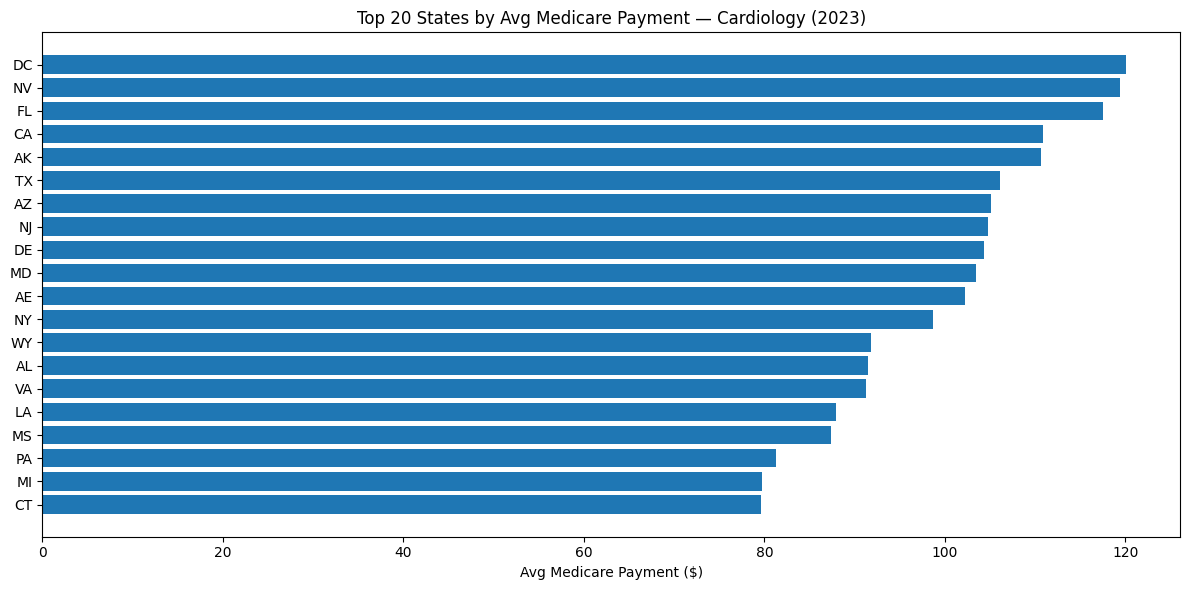

Chart 1 saved.


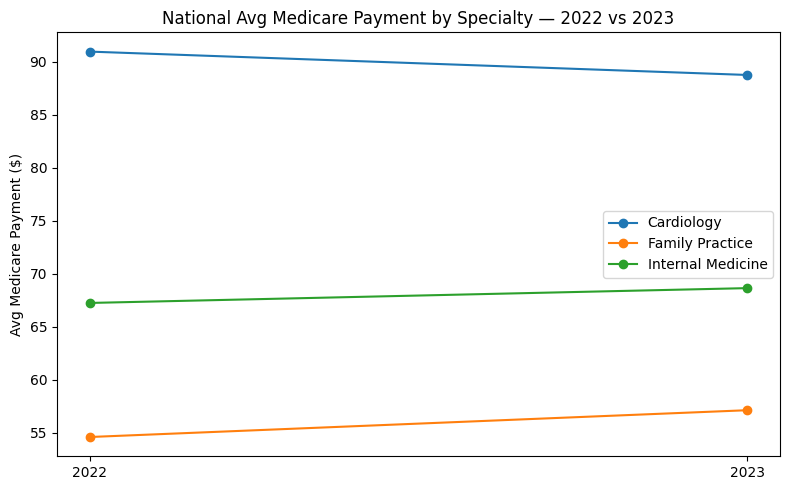

Chart 2 saved.


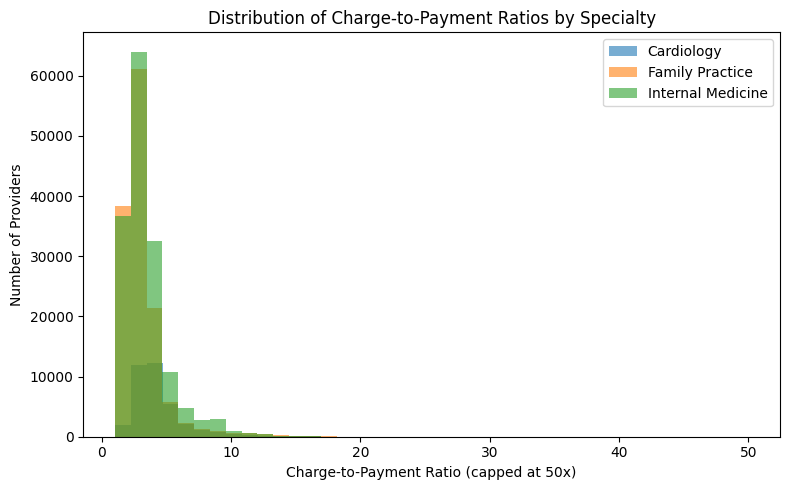

Chart 3 saved.


In [10]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Install if needed — run in terminal: pip install matplotlib

# --- Chart 1: Average Medicare Payment by State (2023, Cardiology only) ---
cardiology_2023 = state_summary[
    (state_summary["Rndrng_Prvdr_Type"] == "Cardiology") &
    (state_summary["year"] == 2023)
].sort_values("avg_payment", ascending=False)

# Filter to contiguous states (remove territories/military codes)
us_states = cardiology_2023[
    cardiology_2023["Rndrng_Prvdr_State_Abrvtn"].str.len() == 2
].head(20)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(us_states["Rndrng_Prvdr_State_Abrvtn"], 
        us_states["avg_payment"], color="#1f77b4")
ax.set_xlabel("Avg Medicare Payment ($)")
ax.set_title("Top 20 States by Avg Medicare Payment — Cardiology (2023)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("chart1_cardiology_payment_by_state.png", dpi=150)
plt.show()
print("Chart 1 saved.")

# --- Chart 2: Payment trend 2022 vs 2023 by specialty (national average) ---
nat_trend = (
    df_filtered
    .groupby(["Rndrng_Prvdr_Type", "year"])["Avg_Mdcr_Pymt_Amt"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))
for specialty, grp in nat_trend.groupby("Rndrng_Prvdr_Type"):
    ax.plot(grp["year"], grp["Avg_Mdcr_Pymt_Amt"], marker="o", label=specialty)
ax.set_xticks([2022, 2023])
ax.set_ylabel("Avg Medicare Payment ($)")
ax.set_title("National Avg Medicare Payment by Specialty — 2022 vs 2023")
ax.legend()
plt.tight_layout()
plt.savefig("chart2_payment_trend_by_specialty.png", dpi=150)
plt.show()
print("Chart 2 saved.")

# --- Chart 3: Outlier distribution — charge-to-payment ratio by specialty ---
fig, ax = plt.subplots(figsize=(8, 5))
for specialty, grp in provider_summary.groupby("Rndrng_Prvdr_Type"):
    # Cap at 50x for readability — extreme outliers compress the chart
    capped = grp["charge_to_payment_ratio"].clip(upper=50)
    ax.hist(capped, bins=40, alpha=0.6, label=specialty)
ax.set_xlabel("Charge-to-Payment Ratio (capped at 50x)")
ax.set_ylabel("Number of Providers")
ax.set_title("Distribution of Charge-to-Payment Ratios by Specialty")
ax.legend()
plt.tight_layout()
plt.savefig("chart3_outlier_distribution.png", dpi=150)
plt.show()
print("Chart 3 saved.")

In [11]:
# --- Final Step: Export summary outputs ---

# Export 1: State summary table
state_summary.to_csv("output_state_summary.csv", index=False)
print("Saved: output_state_summary.csv")

# Export 2: Year-over-year trend table
trend.to_csv("output_trend_yoy.csv", index=False)
print("Saved: output_trend_yoy.csv")

# Export 3: Top outliers (ratio >= 10x, volume >= 100 services)
outliers.to_csv("output_outliers.csv", index=False)
print(f"Saved: output_outliers.csv ({len(outliers):,} providers flagged)")

# Export 4: Quick summary stats for the README
print("\n--- Project Summary Stats ---")
print(f"Total rows analyzed: {len(df):,}")
print(f"Rows after specialty filter: {len(df_filtered):,}")
print(f"States covered: {state_summary['Rndrng_Prvdr_State_Abrvtn'].nunique()}")
print(f"Providers analyzed (volume >= 100): {len(provider_summary):,}")
print(f"Outlier providers flagged (ratio >= 10x): {len(outliers):,}")
print(f"Years covered: 2022, 2023")

Saved: output_state_summary.csv
Saved: output_trend_yoy.csv
Saved: output_outliers.csv (5,229 providers flagged)

--- Project Summary Stats ---
Total rows analyzed: 19,416,074
Rows after specialty filter: 4,027,496
States covered: 60
Providers analyzed (volume >= 100): 327,133
Outlier providers flagged (ratio >= 10x): 5,229
Years covered: 2022, 2023


In [9]:
pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.3 MB 4.0 MB/s eta 0:00:02
   -------- ------------------------------- 1.8/8.3 MB 4.7 MB/s eta 0:00:02
   --------------- ------------------------ 3.1/8.3 MB 5.0 MB/s eta 0:00:02
   --------------------- ------------------ 4.5/8.3 MB 5.5 MB/s eta 0:00:01
   ------------------------------ --------- 6.3/8.3 MB 6.2 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.3 MB 6.8 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 6.5 MB/s  0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ----------------------------------- ---- 2.1/2.3 MB 10.6 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 9.7 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:

In [2]:
import subprocess
subprocess.run(["pip", "install", "pandas"])

CompletedProcess(args=['pip', 'install', 'pandas'], returncode=0)